## Analyse descriptive
# Introduction

Ce rapport présente une analyse descriptive complète des données horaires de qualité de l'air (concentration en PM2.5) collectées en Ile-de-France sur la période 2021-2025. L'objectif est d'identifier les tendances, la saisonnalité et les variations spatiales de la pollution aux particules fines.

Les données proviennent de 18 stations de mesure réparties en Ile-de-France, avec un focus particulier sur les zones urbaines, industrielles et rurales. Les variables analysées incluent la concentration en PM2.5, les conditions météorologiques (température, humidité, vitesse du vent, précipitations) et la densité d'installations industrielles.


In [33]:
import sys
import os
import pandas as pd
sys.path.insert(0, os.path.abspath(".."))

## Importation de la base de données

In [34]:
df = pd.read_csv("https://minio.lab.sspcloud.fr/ganlea/projet-qualite-air/processed/dataset_consolide.csv")
df["datetime_debut"]=pd.to_datetime(df["datetime_debut"])

## 1. ANALYSE DESCRITPIVE DE LA VARIABLE CIBLE (PM2.5)

On commence par une visualisation des types des variables contenues dans la base de données

In [35]:
print(df.dtypes)

datetime_debut          datetime64[us]
code_station                       str
nom_station                        str
type_station                       str
pm25_brute                     float64
lat                            float64
lon                            float64
distance_km                    float64
vent_vitesse_ms                float64
vent_direction_deg             float64
temperature_c                  float64
humidite_pct                   float64
pluie_mm                       float64
annee                            int64
nb_installations_5km           float64
heure                            int64
jour_semaine                     int64
mois                             int64
is_weekend                       int64
saison                             str
pm25_lag1h                     float64
pm25_lag6h                     float64
pm25_lag24h                    float64
pm25_roll24h                   float64
pm25_roll72h                   float64
depasse_seuil_24h        

Une visualisation d'ensemble de chaque variable quantitative permet d'avoir une idée sur la distribution et le comportement de ces variables.

In [36]:
liste_variables_quanti = ["pm25_brute", "vent_vitesse_ms", "vent_direction_deg", "temperature_c", "humidite_pct",
                            "pluie_mm", "nb_installations_5km"]
variables_quantitatives = df[liste_variables_quanti]
variables_quantitatives.describe(include="all")

,pm25_brute,vent_vitesse_ms,vent_direction_deg,temperature_c,humidite_pct,pluie_mm,nb_installations_5km
count,715349.000000,715349.000000,715349.00000,715349.000000,715349.000000,715349.000000,715349.000000
mean,10.145318,3.042125,181.25836,1.295742,75.179683,0.078153,5.153757
std,7.934473,1.817580,107.32415,0.718722,17.635846,0.508852,6.384203
min,0.000000,0.000000,0.00000,-1.070000,13.000000,0.000000,0.000000
25%,4.975000,1.800000,80.00000,0.800000,63.000000,0.000000,0.000000
50%,8.000000,2.800000,200.00000,1.250000,79.000000,0.000000,3.000000
75%,12.825000,4.000000,260.00000,1.790000,90.000000,0.000000,8.000000
max,190.325000,17.800000,360.00000,4.040000,100.000000,39.100000,22.000000


PM2.5 (Particules fines) : La moyenne observée est de 10.15 µg/m³, bien en dessous du seuil réglementaire de 25 µg/m³. Cependant, l'écart-type de 7.93 indique une forte variabilité. Le maximum atteint 190.33 µg/m³, suggérant des pics de pollution importants. La médiane (8.00) étant inférieure à la moyenne, la distribution est asymétrique vers la droite.

Vent (Vitesse) : Vitesse moyenne de 3.04 m/s, relativement modérée. L'écart-type de 1.82 m/s indique une variabilité normale. Les vitesses varient de 0 m/s (calme plat) à 17.8 m/s (venteux).

Température : La température moyenne observée est de 13°C. L'écart-type de 7.2°C suggère des variations saisonnières modérées. Les valeurs négatives (-10.7°C) et positives (40.4°C) indiquent la présence de périodes hivernales et estivales.

Humidité : Humidité moyenne de 75.18%, plutôt élevée. La distribution est concentration entre 63% (Q1) et 90% (Q3), suggérant un climat humide.

Pluie : Précipitations moyennes très faibles (0.08 mm/heure), avec 75% des observations sans pluie. Cela reflète le fait que les précipitations sont des événements localisés dans le temps.

Industries (densité dans rayon 5km) : Moyenne de 5.15 installations par station, avec forte variabilité (6.38). Les zones rurales peuvent avoir 0 industrie, tandis que certains sites près de zones industrielles en comptent jusqu'à 22. C'est une proxy de la pollution locale d'origine structurelle.

On vérifiera dans la suite la pertinence de ces variables dans notre analyse.


### Diagramme en barre des dépassements de seuil de concentration de PM2.5

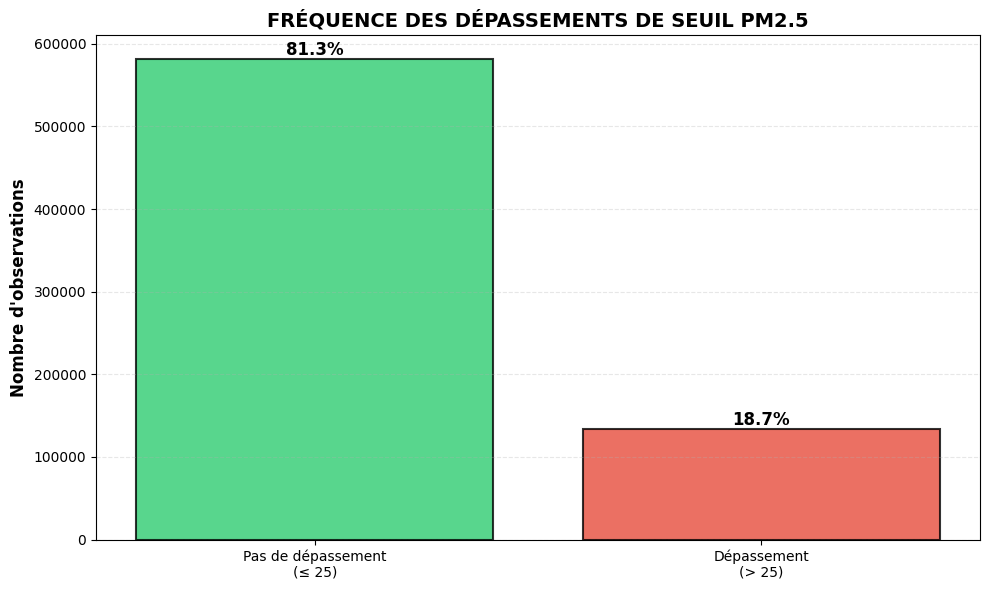

None


In [37]:
from src.data_preprocessing import graphique_frequence_depassement

print(graphique_frequence_depassement(df, "depasse_seuil_24h"))

Ce graphique illustre la distribution binaire de la conformité réglementaire des concentrations en PM2.5 en Île-de-France sur la période 2021-2025, basée sur le seuil européen de 25 µg/m³. L'analyse révèle une asymétrie marquée : 81.3% des observations restent en dessous du seuil, tandis que 18.7%  le dépassent. Cette distribution montre que, bien que la qualité de l'air générale soit acceptable, des épisodes de pollution significatifs surviennent régulièrement. Le taux de dépassement de 18.7% équivaut à environ 1 jour sur 5.4 où les concentrations excèdent la limite réglementaire.


### Diagramme en barre des stations avec les mesures de concentrations moyennes les plus hautes et les plus basses


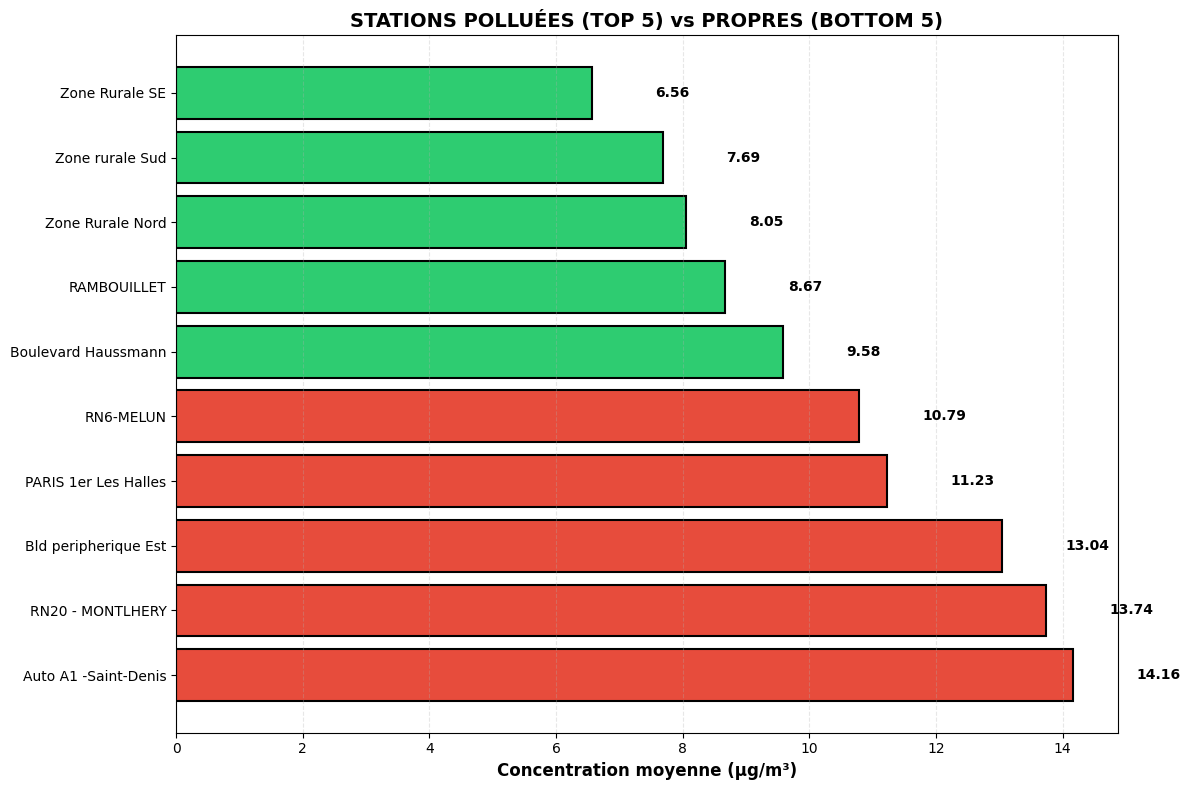

None


In [38]:
from src.data_preprocessing import graphique_top_bottom_stations

print(graphique_top_bottom_stations(df, n=5, colonne="pm25_brute", station="nom_station"))

Ce graphique en barres horizontales compare les concentrations moyennes de PM2.5 entre les 5 stations les plus polluées (en rouge) et les 5 moins polluées (en vert) en Île-de-France. Les résultats révèlent ce qui suit : Auto A1 Saint-Denis enregistre 14.16 µg/m³ (2.16× supérieur à Zone Rurale SE avec 6.56 µg/m³), un écart de 7.60 µg/m³. Les stations routières dominent le classement des plus polluées (Auto A1, RN20, Bld Périphérique à 13.04-14.16 µg/m³), reflétant l'impact direct du trafic automobile intensif et des émissions d'échappement. À l'inverse, les zones rurales (Zones Rurale SE/Sud/Nord à 6.56-8.05 µg/m³) bénéficient d'une meilleure ventilation atmosphérique et d'une distance aux sources d'émission. Les stations urbaines parisiennes (Paris 1er, Boulevard Haussmann à 9.58-11.23 µg/m³) occupent une position intermédiaire.

### Distribution de concentration de PM2.5

(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'Distribution de PM2.5'}, xlabel='PM2.5 (µg/m³)', ylabel='Densité'>)


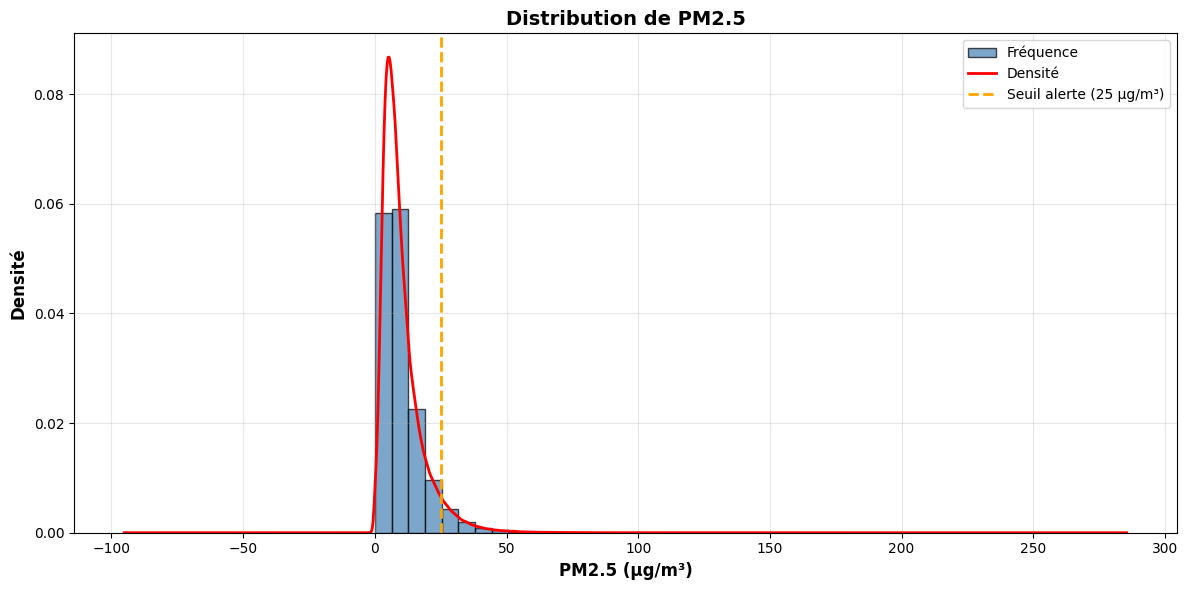

In [39]:
from src.data_preprocessing import graphique_histogramme_pm25

print(graphique_histogramme_pm25(df, colonne="pm25_brute"))

Ce graphique superpose l'histogramme de fréquence (barres bleues) et la courbe de densité KDE (ligne rouge) des concentrations en PM2.5, révélant une distribution fortement asymétrique vers la droite. Le pic principal concentre les observations autour de 8 µg/m³ (la médiane), confirmant que la majorité des mesures reste bien en dessous du seuil alerte (ligne pointillée jaune à 25 µg/m³). Cependant, la queue de distribution s'étend jusqu'à environ 200 µg/m³, indiquant des valeurs extrêmes rares mais significatives. Cette forme est caractéristique des données de pollution environnementale où les conditions normales dominent mais des événements exceptionnels (inversions thermiques, épisodes transfrontaliers) génèrent des pics isolés.

### Boxplot de la concentration de PM2.5

(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'Boxplot - PM2.5 (Global)'}, ylabel='PM2.5 (µg/m³)'>)


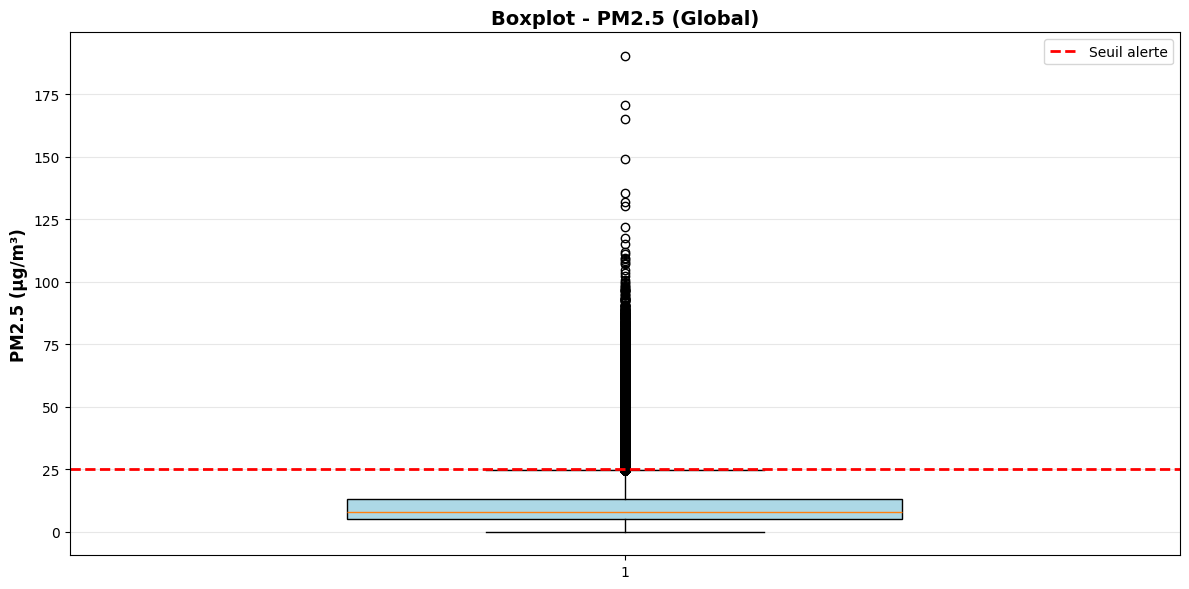

In [40]:
from src.data_preprocessing import graphique_boxplot_global

print(graphique_boxplot_global(df, colonne="pm25_brute"))

Ce boxplot synthétise la distribution complète des PM2.5 à travers une représentation robuste des quartiles et des valeurs extrêmes. Le seuil alerte (25 µg/m³, ligne pointillée rouge) dépasse largement la boîte, révélant que les dépassements nécessitent une accumulation significative de polluants au-delà des conditions normales. Les points noirs au-dessus de la boîte représentent des valeurs extrêmes. Ces observations confirment les analyses faites jusqu'à présent.

## 2. ANALYSE TEMPORELLE DE LA VARIABLE CIBLE (PM2.5)

### Analyse de l'évolution mensuelle de la concentration de PM2.5

Statistiques PM2.5 par Mois 
 
 
 Moyennes, écarts-types, minima et maxima 
 
 
 Mois 
 Moyenne 
 Écart-type 
 Min 
 Max 
 
 
 
 
 Jan 
 13.75 
 11.19 
 0.00 
 135.48 
 
 
 Fév 
 13.51 
 10.83 
 0.00 
 102.18 
 
 
 Mar 
 13.98 
 10.71 
 0.00 
 84.52 
 
 
 Avr 
 10.00 
 6.55 
 0.00 
 77.18 
 
 
 Mai 
 8.61 
 5.26 
 0.00 
 170.55 
 
 
 Juin 
 8.99 
 5.38 
 0.00 
 190.32 
 
 
 Juil 
 7.32 
 4.75 
 0.00 
 107.38 
 
 
 Août 
 7.28 
 4.27 
 0.00 
 59.25 
 
 
 Sep 
 7.79 
 5.22 
 0.00 
 54.88 
 
 
 Oct 
 8.79 
 5.93 
 0.00 
 165.12 
 
 
 Nov 
 10.08 
 7.47 
 0.00 
 87.98 
 
 
 Déc 
 11.93 
 8.67 
 0.00 
 121.75

None
Figure(1200x600)


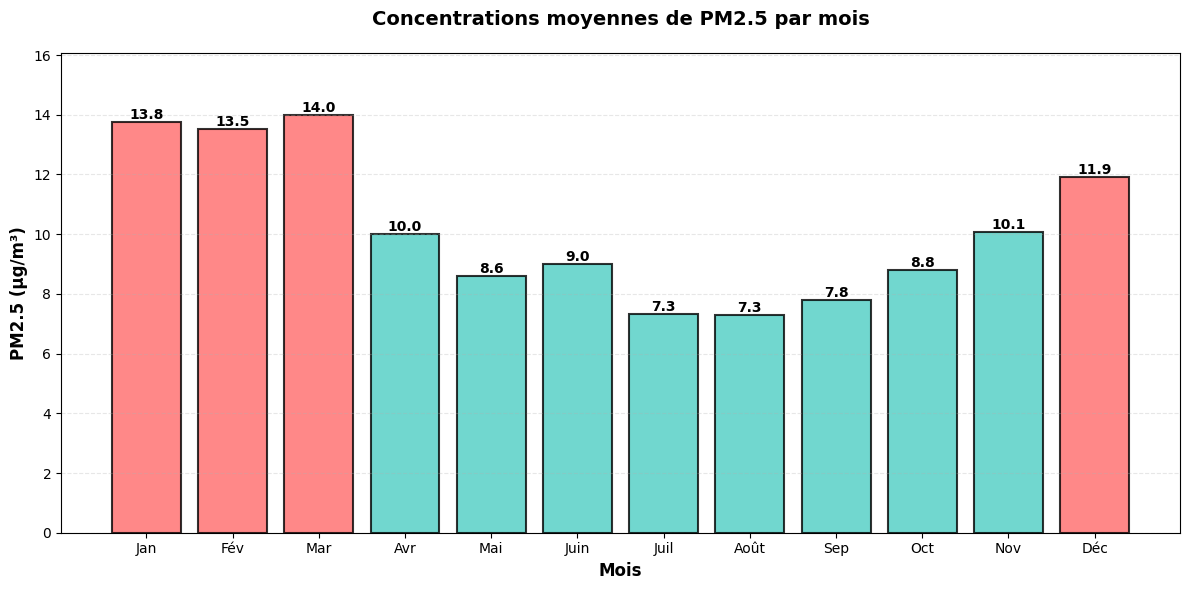

In [41]:
from src.data_preprocessing import tableau_moyennes_mensuelles, graphique_moyennes_mensuelles

print(tableau_moyennes_mensuelles(df, "pm25_brute", "mois"))
print(graphique_moyennes_mensuelles(df, "pm25_brute", "mois"))

Ce tableau et ce graphique révèlent un cycle saisonnier extrêmement marqué. Les moyennes varient de 13.98 µg/m³ (mars, pic hivernal) à 7.28 µg/m³ (août, creux estival), soit une amplitude saisonnière de 92% (ratio 1.92 entre max et min). L'hiver (janvier-mars) concentre les concentrations les plus élevées (13.51-13.98 µg/m³) avec des écarts-types importants (10.71-11.19), indiquant une grande variabilité intra-mensuelle due aux inversions thermiques intermittentes et au chauffage résidentiel intensif. L'été (juillet-septembre) enregistre les niveaux minimaux (7.28-7.79 µg/m³) avec écarts-types réduits (4.27-5.22), confirmant des conditions stables et favorables à la dispersion. On remarque également des transitions saisonnières nettes : avril marque une chute abrupte de 28%, tandis que novembre et décembre amorçent progressivement la remontée hivernale.

### Analyse de l'évolution saisonnier de la concentration de PM2.5

Figure(1000x600)


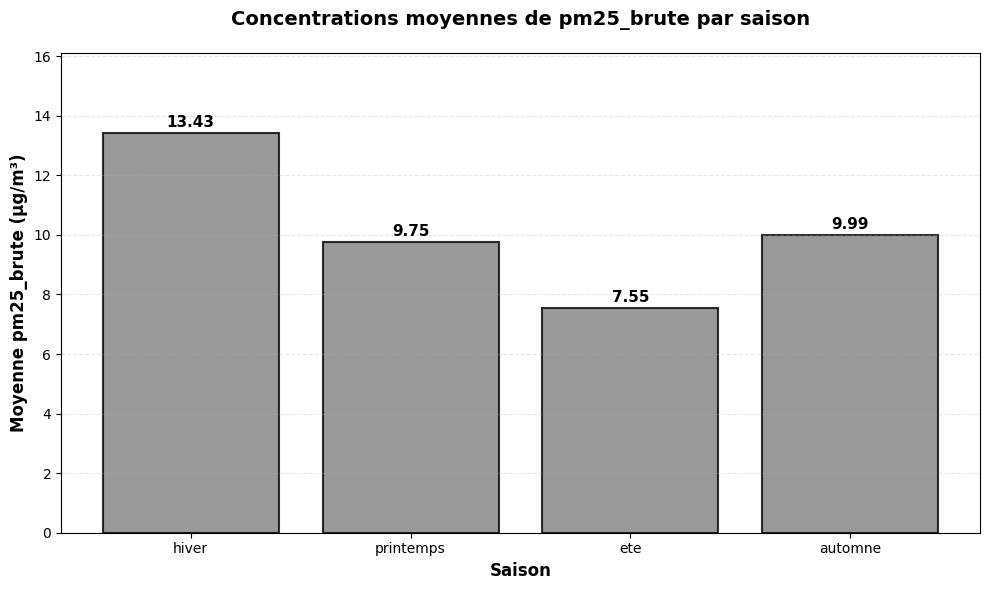

In [42]:
from src.data_preprocessing import graphique_moyennes_saisonnieres

print(graphique_moyennes_saisonnieres(df, "pm25_brute", "saison"))

Ces résultats viennent confirmés les observations faites plus haut.

### Analyse de l'évolution journalière de la concentration de PM2.5

(<Figure size 1400x600 with 1 Axes>, <Axes: title={'center': 'Série Temporelle - PM2.5'}, xlabel='Date', ylabel='PM2.5 (µg/m³)'>)


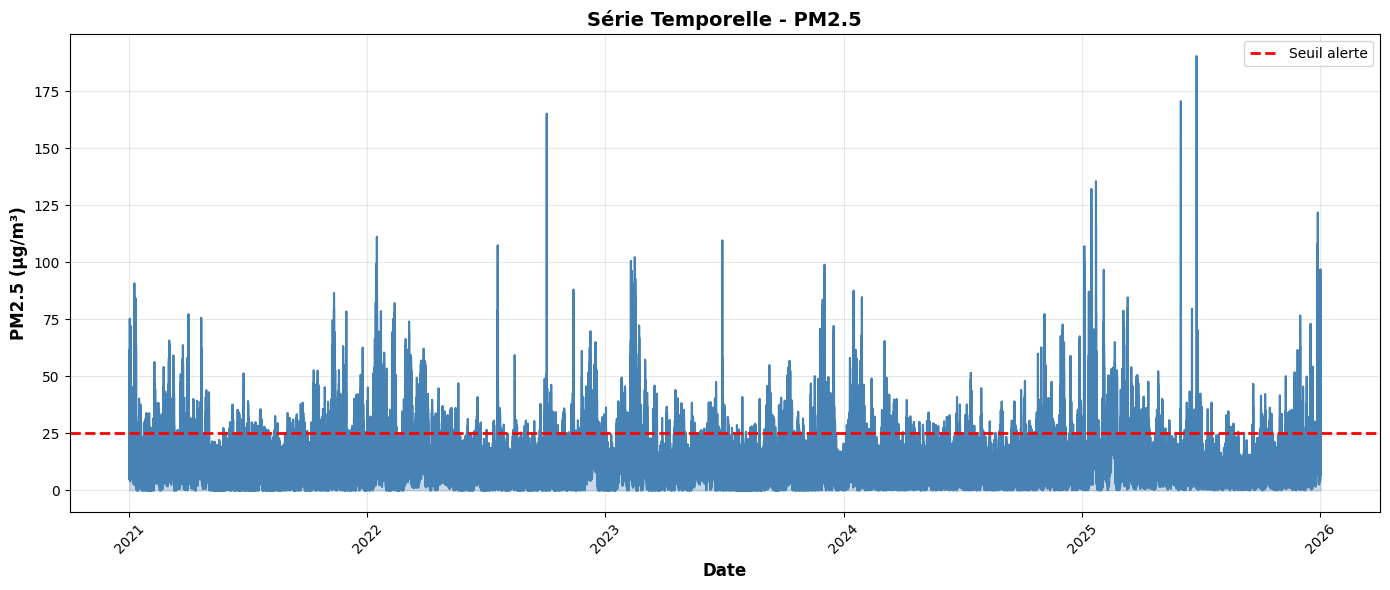

In [44]:
from src.data_preprocessing import graphique_serie_temporelle

print(graphique_serie_temporelle(df, "pm25_brute", "datetime_debut"))

Cette série temporelle de mesures horaires révèle la dynamique complète de la pollution aux PM2.5 en Île-de-France avec une granularité fine permettant d'identifier cycles saisonniers, événements extrêmes et tendances à long terme. Le graphique exhibe un pattern saisonnier : les concentrations sont systématiquement élevées en hiver (janvier-mars de chaque année) et minimales en été (juillet-septembre). Cette répétition annuelle confirme que la saisonnalité est le principal moteur de la variabilité des PM2.5. Le seuil alerte (25 µg/m³, ligne pointillée rouge) est dépassé, mais ces dépassements ne sont pas uniformément distribués : ils se concentrent massivement en hiver (clusters denses novembre-mars) et disparaissent quasi-complètement en été (juin-septembre).

### Analyse de l'évolution journalière de la concentration de PM2.5 dans la semaine

In [45]:
from src.data_preprocessing import tableau_moyennes_jour_semaine

print(tableau_moyennes_jour_semaine(df, "pm25_brute", "jour_semaine"))

Statistiques PM2.5 par Jour de la Semaine 
 
 
 Moyennes, écarts-types et nombre d'observations 
 
 
 Jour 
 Moyenne 
 Écart-type 
 Nombre obs 
 
 
 
 
 Lundi 
 9.69 
 7.11 
 102,312 
 
 
 Mardi 
 10.46 
 8.45 
 102,356 
 
 
 Mercredi 
 10.70 
 8.80 
 102,108 
 
 
 Jeudi 
 10.26 
 7.72 
 101,612 
 
 
 Vendredi 
 10.34 
 7.92 
 102,443 
 
 
 Samedi 
 10.12 
 8.05 
 102,446 
 
 
 Dimanche 
 9.45 
 7.27 
 102,072

None


/home/onyxia/work/projet-qualite-air/src/data_preprocessing.py:382: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=jour_semaine, y=colonne, ax=ax, palette=colors)
/home/onyxia/work/projet-qualite-air/src/data_preprocessing.py:384: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(day_labels)


(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'Boxplots par Jour de la Semaine - PM2.5'}, xlabel='Jour de la semaine', ylabel='PM2.5 (µg/m³)'>)


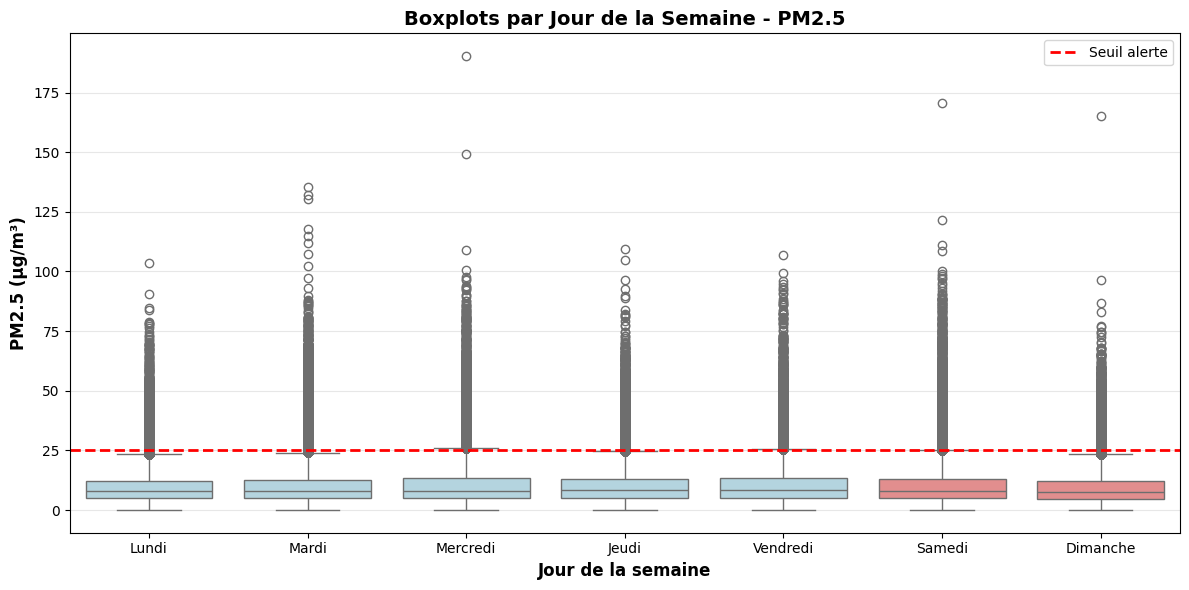

In [46]:
from src.data_preprocessing import graphique_boxplot_jour_semaine

print(graphique_boxplot_jour_semaine(df, "pm25_brute", "jour_semaine"))

(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'Cycle Diurne - PM2.5 (Profil horaire moyen)'}, xlabel='Heure du jour', ylabel='PM2.5 moyen (µg/m³)'>)


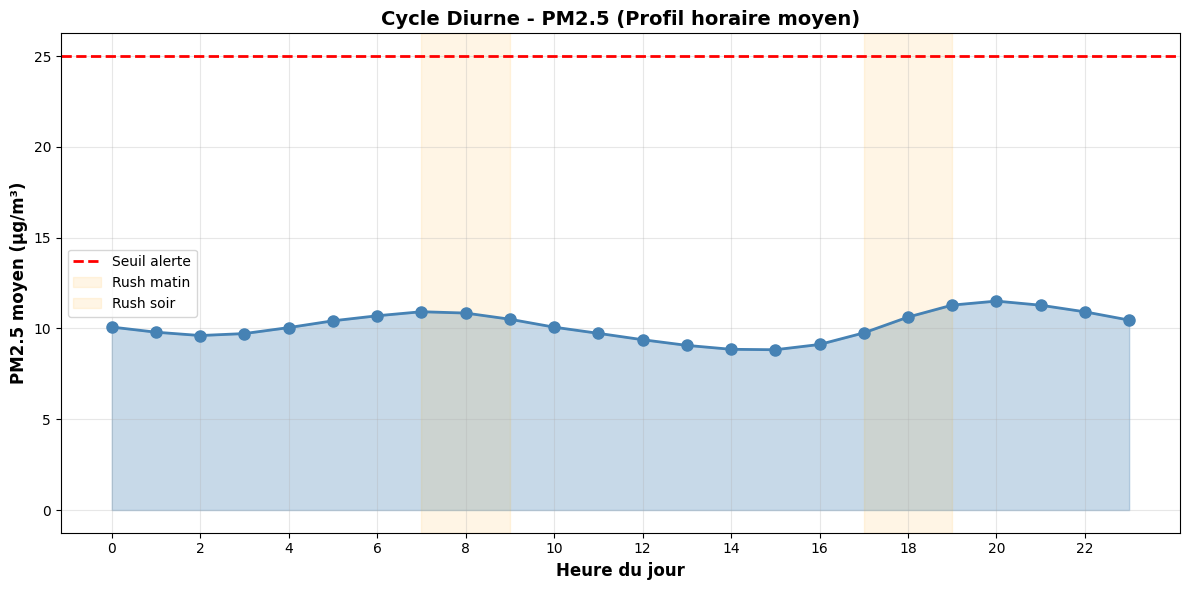

In [47]:
from src.data_preprocessing import graphique_cycle_diurne

print(graphique_cycle_diurne(df, "pm25_brute", "heure"))

On remarque que le profil horaire révèle un cycle diurne très faible. Les concentrations fluctuent faiblement entre 8.8 µg/m³ (14h-16h) et 11.3 µg/m³ (19h-20h). Les deux zones colorées (rush matin 6h-8h et rush soir 17h-20h) montrent que le trafic automobile a un faible impact sur les PM2.5.Les boxplots et le tableau confirment une variabilité hebdomadaire très modérée. Le mercredi est légèrement plus pollué (moyenne 10.70, écart-type 8.80) tandis que le dimanche est le moins pollué (9.45, 7.27), mais cet écart de 1.25 µg/m³ (11%) est minime comparé à la saisonnalité (92%). On ne remarque pas de signature week-end marquée : le samedi (10.12) et dimanche (9.45) ne sont pas beaucoup plus propres que le mercredi (10.70). Les outliers sont distribués uniformément sur tous les jours, indiquant que les événements extrêmes ne sont pas liés au cycle hebdomadaire. Cette quasi-absence de signal jour-de-semaine suggère que le signal prédictif principal reste saisonnier.



### Analyse de l'effet jour-heure sur la concentration des PM2.5

(<Figure size 1400x800 with 2 Axes>, <Axes: title={'center': 'Heatmap - PM2.5 (Heure & Jour de la semaine)'}, xlabel='Heure du jour', ylabel='Jour de la semaine'>)


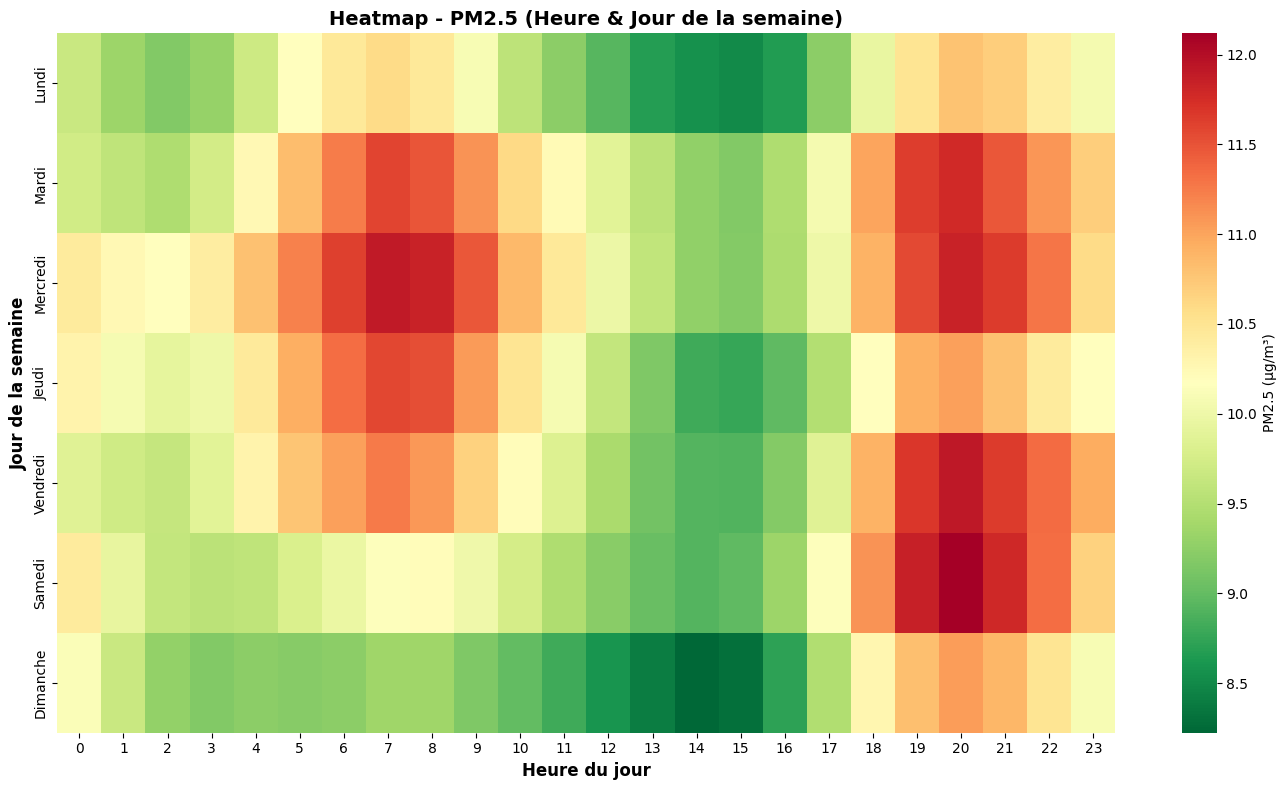

In [48]:
from src.data_preprocessing import graphique_heatmap_heure_jour

print(graphique_heatmap_heure_jour(df, "pm25_brute", "heure", "jour_semaine"))

Cette heatmap révèle des foyers de pollution significatifs identifiables par les teintes orange-rouge (11.0-12.0 µg/m³), formant un pattern cohérent et répétitif sur 5 jours consécutifs (mardi à samedi). Le mardi affiche les zones rouges les plus intenses, avec une première hausse importante de 6h à 13h (rouge-orange soutenu, 11.5-12.0 µg/m³), particulièrement accentuée entre 9h-12h (pics rouges clairs), suivie d'une deuxième surge soirée entre 18h-22h (orange-rouge, 11.0-11.5 µg/m³). Le mercredi présente le pattern le plus extrême et prolongé : une bande rouge quasi-continue et soutenue de 5h à 14h. Le jeudi maintient des teintes orange-rouge importants entre 5h et 13h, bien que légèrement moins intenses que mercredi. Le vendredi conserve une bande orange nettement visible de 6h à 13h (11.0-11.5 µg/m³) et une nouvelle zone orange-rouge entre 18h-22h (11.0-11.5 µg/m³), prolongeant le pattern de 4 jours. Le samedi affiche encore des teintes orange-rouge substantiels de 17h à 22h (11.0-11.5 µg/m³), marquant la dernière manifestation du phénomène avant la chute drastique vers dimanche. Ces teintes chaudes systématiques de mardi à samedi constituent un signal prédictif majeur et justifient pleinement l'inclusion de variables jour-de-semaine et heure dans le modèle, contrairement à ce que suggérait la faiblesse apparente des signaux isolés.

## 3. ANALYSE SPATIALE DE LA VARIABLE CIBLE (PM2.5)

In [49]:
from src.data_preprocessing import tableau_comparaison_stations

print(tableau_comparaison_stations(df, "nom_station", "pm25_brute", "depasse_seuil_24h", "datetime_debut", "nb_installations_5km"))

Tableau Comparatif par Station 
 
 
 Moyennes PM2.5, écarts-types, taux de dépassement et nombre d'observations 
 
 
 Station 
 Moy PM2.5 
 Sd PM2.5 
 Nb obs 
 Taux dépassement % 
 
 
 
 
 Auto A1 -Saint-Denis 
 14.16 
 8.53 
 43,328 
 35.0 
 
 
 RN20 - MONTLHERY 
 13.74 
 9.36 
 38,901 
 37.0 
 
 
 Bld peripherique Est 
 13.04 
 8.41 
 43,419 
 30.0 
 
 
 PARIS 1er Les Halles 
 11.23 
 8.04 
 43,609 
 20.0 
 
 
 RN6-MELUN 
 10.79 
 7.61 
 43,534 
 20.0 
 
 
 Av Champs Elysees 
 10.34 
 6.89 
 26,093 
 16.0 
 
 
 GENNEVILLIERS 
 10.26 
 8.72 
 42,786 
 20.0 
 
 
 PARIS 18eme 
 9.94 
 8.09 
 33,767 
 18.0 
 
 
 GONESSE 
 9.81 
 7.66 
 43,018 
 19.0 
 
 
 VITRY-SUR-SEINE 
 9.81 
 7.99 
 43,655 
 17.0 
 
 
 LA DEFENSE 
 9.78 
 7.4 
 26,685 
 16.0 
 
 
 BOBIGNY 
 9.63 
 7.83 
 43,348 
 17.0 
 
 
 RD934 Coulommiers 
 9.62 
 8.07 
 34,106 
 18.0 
 
 
 Boulevard Haussmann 
 9.58 
 6.53 
 34,747 
 13.0 
 
 
 RAMBOUILLET 
 8.67 
 7.31 
 43,769 
 14.0 
 
 
 Zone Rurale Nord 
 8.05 
 6.76 
 43,410 
 12.0 
 
 
 Zone rurale Sud 
 7.69 
 6.42 
 43,624 
 9.0 
 
 
 Zone Rurale SE 
 6.56 
 5.51 
 43,550 
 6.0

None


/home/onyxia/work/projet-qualite-air/src/data_preprocessing.py:553: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=station, y=colonne, ax=ax, palette='Set2')


(<Figure size 1400x600 with 1 Axes>, <Axes: title={'center': 'Boxplots par Station - PM2.5'}, xlabel='Station', ylabel='PM2.5 (µg/m³)'>)


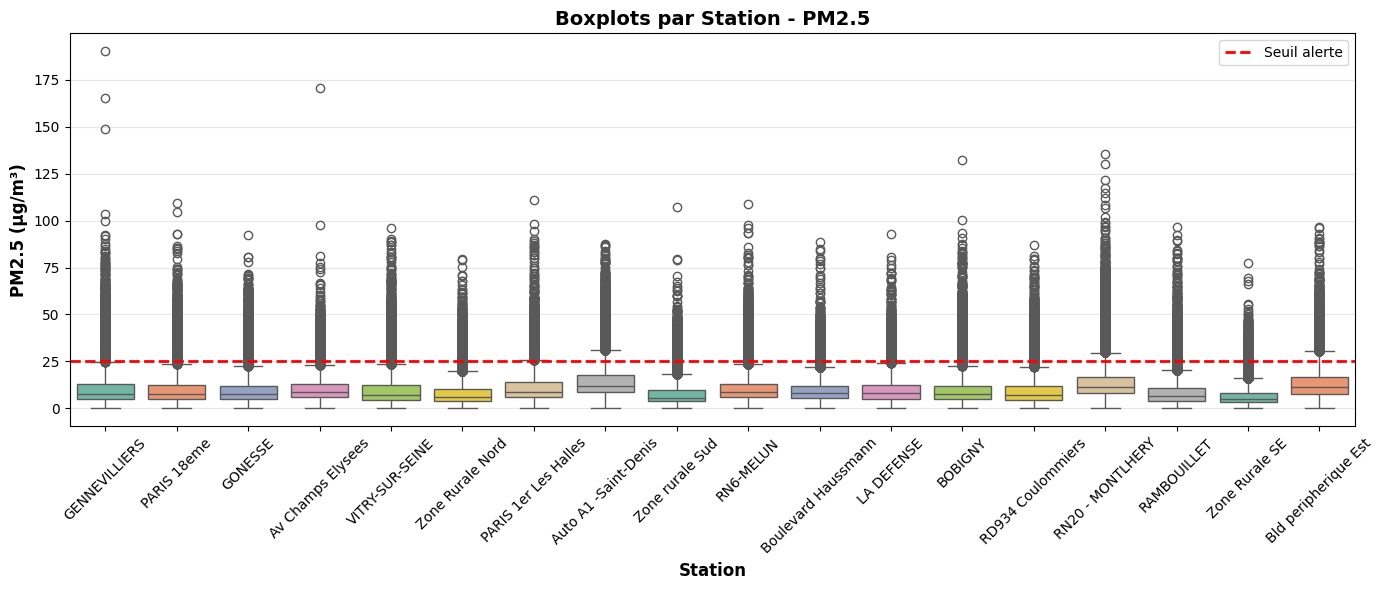

In [50]:
from src.data_preprocessing import graphique_boxplot_stations

print(graphique_boxplot_stations(df, "nom_station", "pm25_brute"))

(<Figure size 1400x600 with 1 Axes>, <Axes: title={'center': 'Nombre Cumulé de Dépassements par Station'}, xlabel='Station', ylabel='Nombre de dépassements'>)


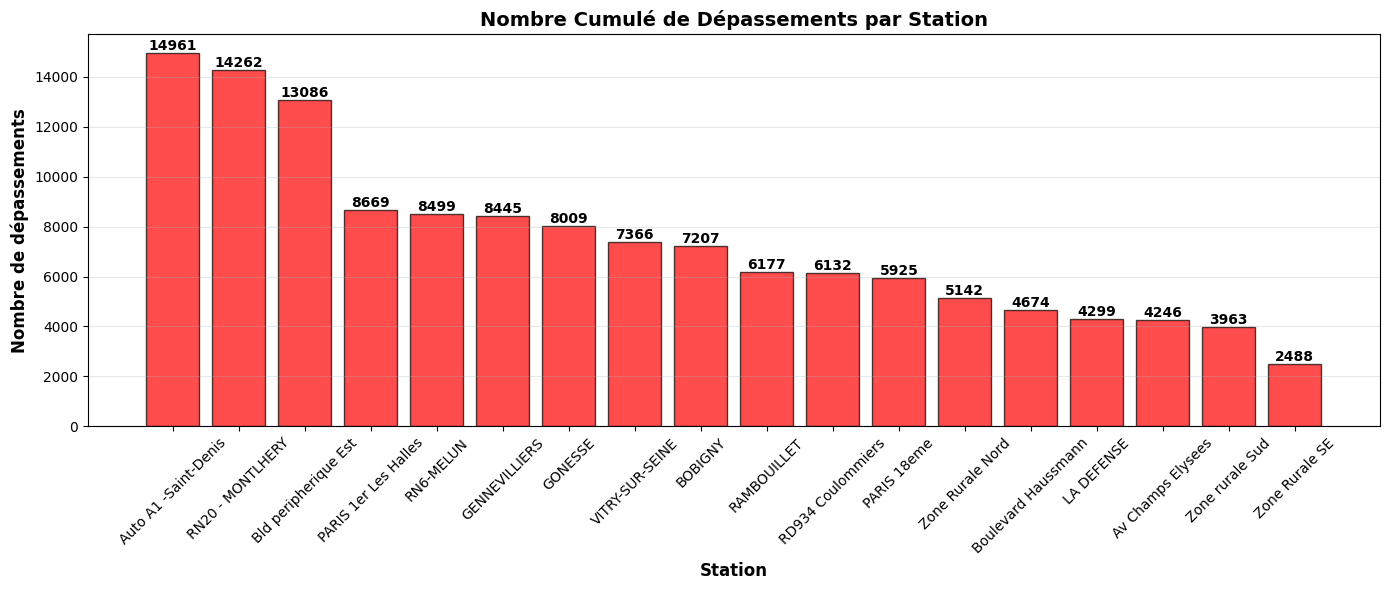

In [51]:
from src.data_preprocessing import graphique_bar_depassements_stations

print(graphique_bar_depassements_stations(df, "nom_station", "depasse_seuil_24h"))

Ces sorties révèlent des disparités spatiales extrêmes et systématiques. Les concentrations moyennes varient fortement : Auto A1 Saint-Denis atteint 14.16 µg/m³ (plus polluée) tandis que Zone Rurale SE affiche 6.56 µg/m³ (moins polluée). Les stations routières dominent le classement supérieur : Auto A1 (14.16), RN20-Montlhéry (13.74), Bld Périphérique Est (13.04), toutes concentrant le trafic intensif automobile et affichant les écarts-types les plus élevés (8.41-8.53), traduisant une grande variabilité intra-station due aux fluctuations du trafic. Les stations urbaines parisiennes (PARIS 1er Les Halles 11.23, Av Champs-Élysées 10.34, Boulevard Haussmann 9.58) occupent une position intermédiaire, bénéficiant de mesures de régulation du trafic (zones piétonnes, limitation vitesse) tout en restant exposées aux émissions. Les zones industrielles (Gennevilliers 10.26, Bobigny 9.63, Gonesse 9.81) affichent des concentrations modérées, suggérant que la pollution industrielle pèse moins que la proximité routière. Les zones rurales (Zones Rurale Nord/Sud/SE à 6.56-8.05) constituent un groupe homogène et nettement moins pollué, avec écarts-types minimaux (5.51-6.76), témoignant de conditions atmosphériques stables et loin des sources d'émission.

## 4. ANALYSE DES CORRÉLATIONS (VARIABLES MÉTÉO ET D'INFRASTRUCTURES) AVEC LA VARIABLE CIBLE PM2.5

(<Figure size 1200x1000 with 2 Axes>, <Axes: title={'center': 'Heatmap - Matrice de Corrélation (Spearman)'}>)


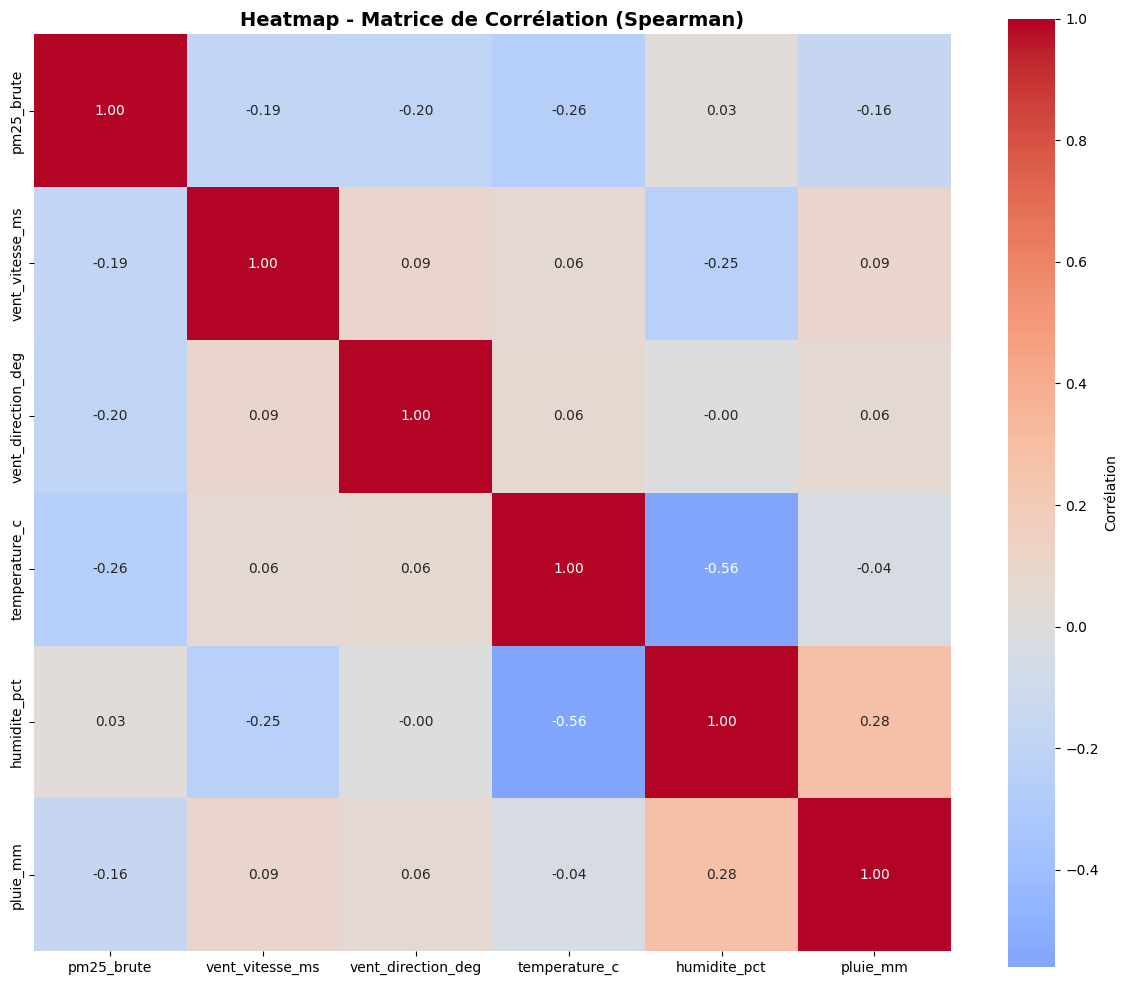

In [52]:
from src.data_preprocessing import graphique_heatmap_correlation
list_variable = ["pm25_brute", "vent_vitesse_ms", "vent_direction_deg", "temperature_c", "humidite_pct", "pluie_mm"]
print(graphique_heatmap_correlation(df, list_variable))

/home/onyxia/work/projet-qualite-air/src/data_preprocessing.py:744: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'PM2.5 (µg/m³) vs Vitesse du vent (r = -0.186)'}, xlabel='Vitesse du vent', ylabel='PM2.5 (µg/m³)'>)


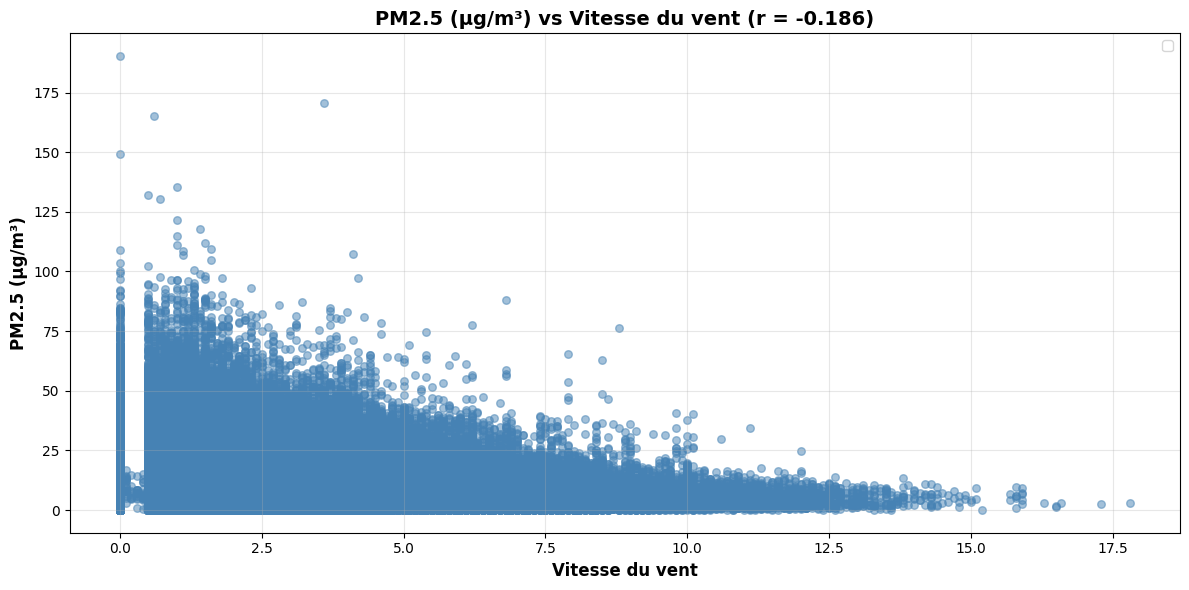

In [53]:
from src.data_preprocessing import graphique_scatter_pm25

print(graphique_scatter_pm25(df, "vent_vitesse_ms", "pm25_brute", "Vitesse du vent", "PM2.5 (µg/m³)"))

(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'Distribution de vent_vitesse_ms par dépassement de seuil'}, xlabel='vent_vitesse_ms', ylabel='Densité'>)


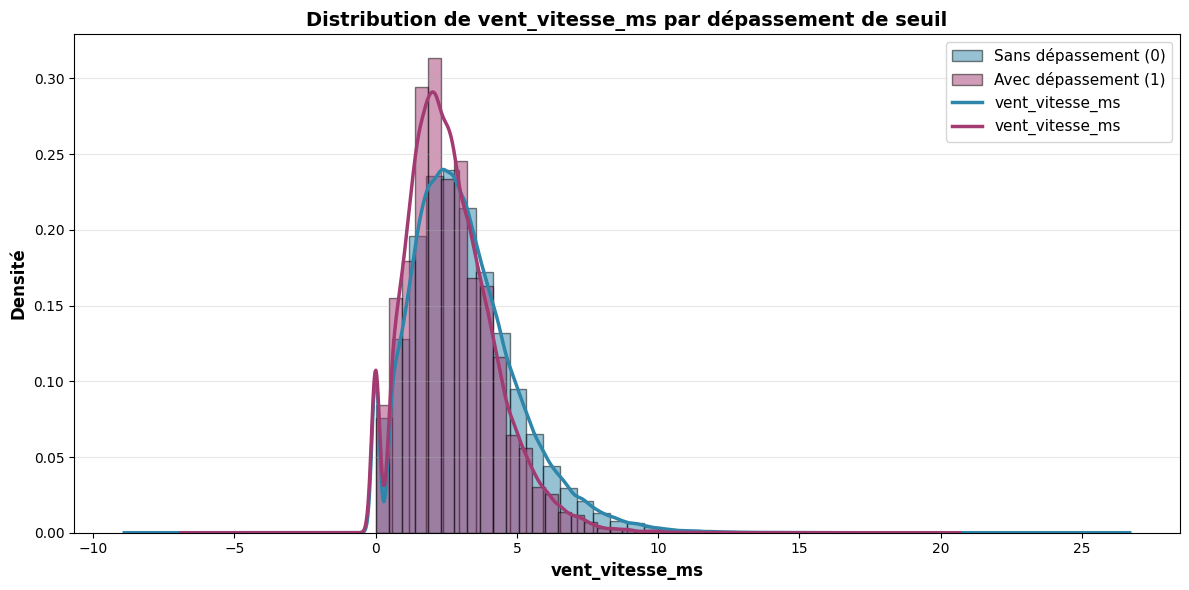

In [54]:
from src.data_preprocessing import histogramme_densité_superposée

print(histogramme_densité_superposée(df, "vent_vitesse_ms"))

/home/onyxia/work/projet-qualite-air/src/data_preprocessing.py:744: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'PM2.5 (µg/m³) vs Direction du vent (r = -0.195)'}, xlabel='Direction du vent', ylabel='PM2.5 (µg/m³)'>)


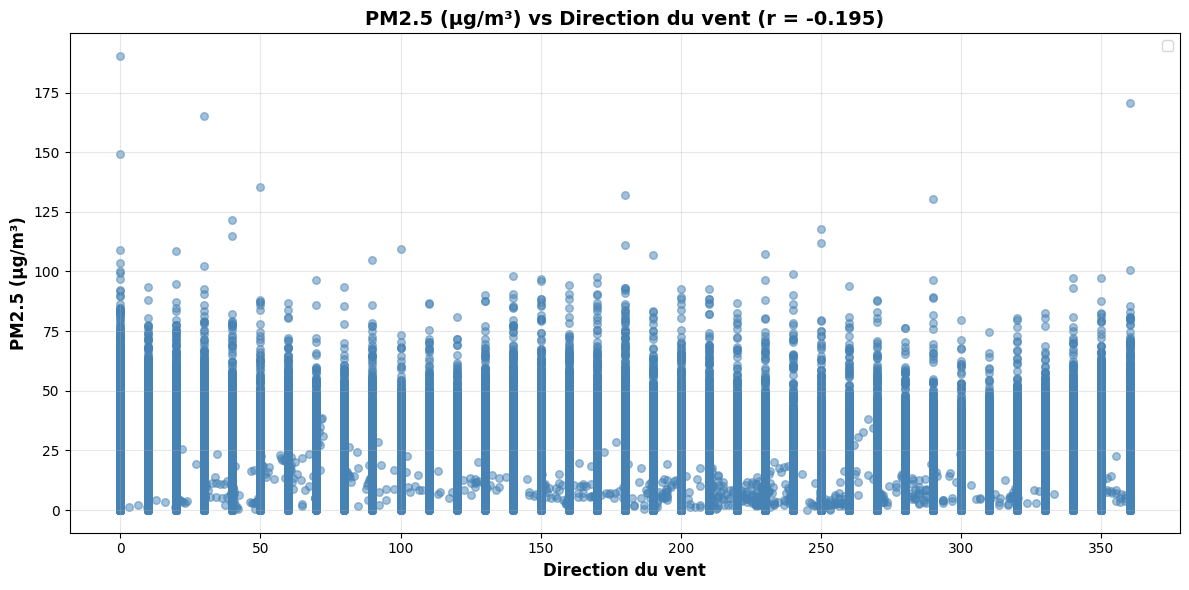

In [55]:
from src.data_preprocessing import graphique_scatter_pm25

print(graphique_scatter_pm25(df, "vent_direction_deg", "pm25_brute", "Direction du vent", "PM2.5 (µg/m³)"))

(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'Distribution de vent_direction_deg par dépassement de seuil'}, xlabel='vent_direction_deg', ylabel='Densité'>)


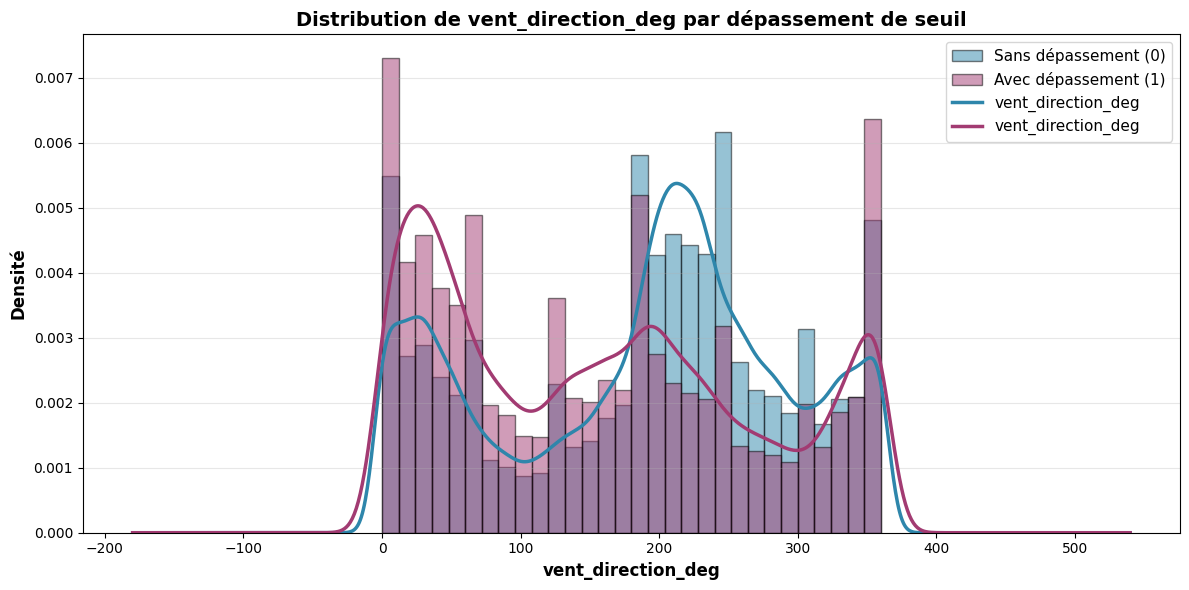

In [56]:
from src.data_preprocessing import histogramme_densité_superposée

print(histogramme_densité_superposée(df, "vent_direction_deg"))

/home/onyxia/work/projet-qualite-air/src/data_preprocessing.py:744: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'PM2.5 (µg/m³) vs Température (r = -0.258)'}, xlabel='Température', ylabel='PM2.5 (µg/m³)'>)


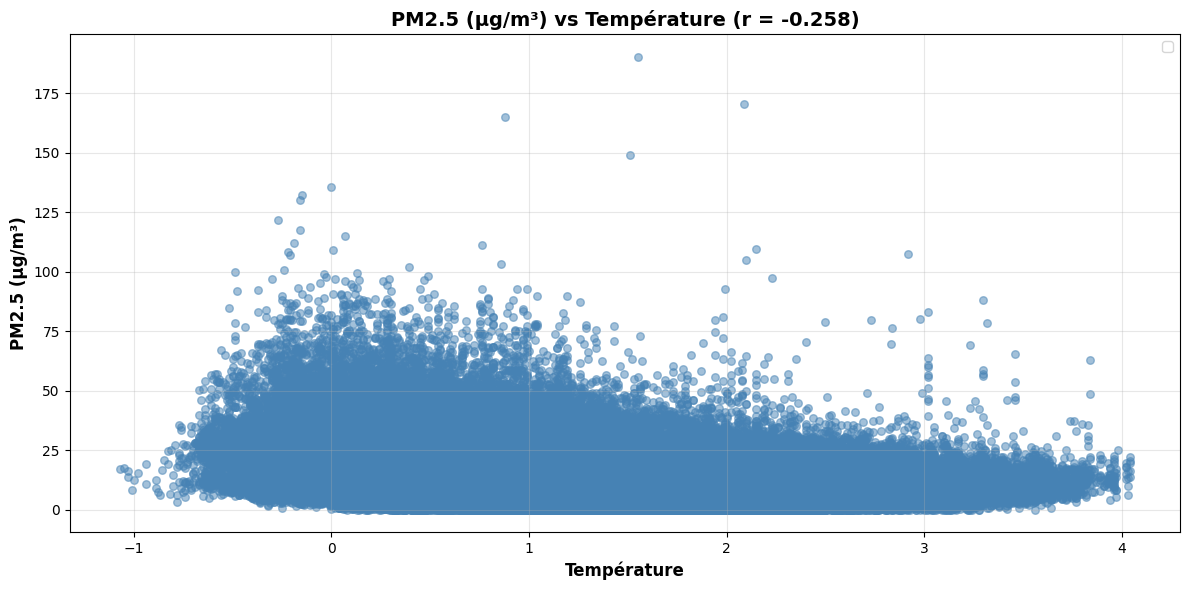

In [57]:
from src.data_preprocessing import graphique_scatter_pm25

print(graphique_scatter_pm25(df, "temperature_c", "pm25_brute", "Température", "PM2.5 (µg/m³)"))

(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'Distribution de temperature_c par dépassement de seuil'}, xlabel='temperature_c', ylabel='Densité'>)


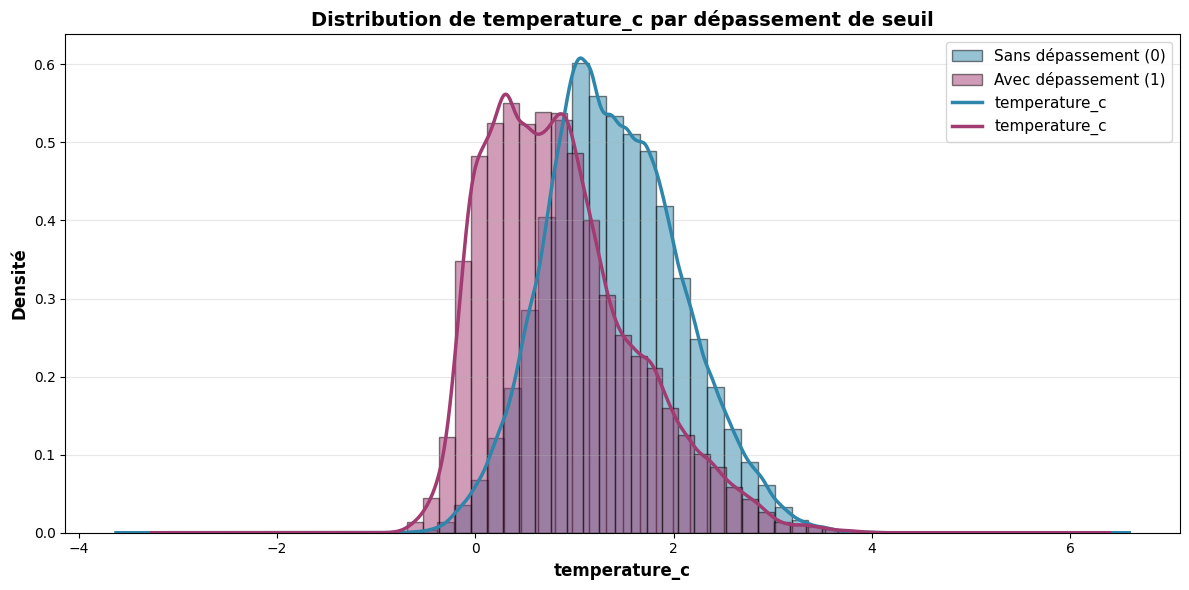

In [58]:
from src.data_preprocessing import histogramme_densité_superposée

print(histogramme_densité_superposée(df, "temperature_c"))

/home/onyxia/work/projet-qualite-air/src/data_preprocessing.py:744: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'PM2.5 (µg/m³) vs Humidité (r = 0.030)'}, xlabel='Humidité', ylabel='PM2.5 (µg/m³)'>)


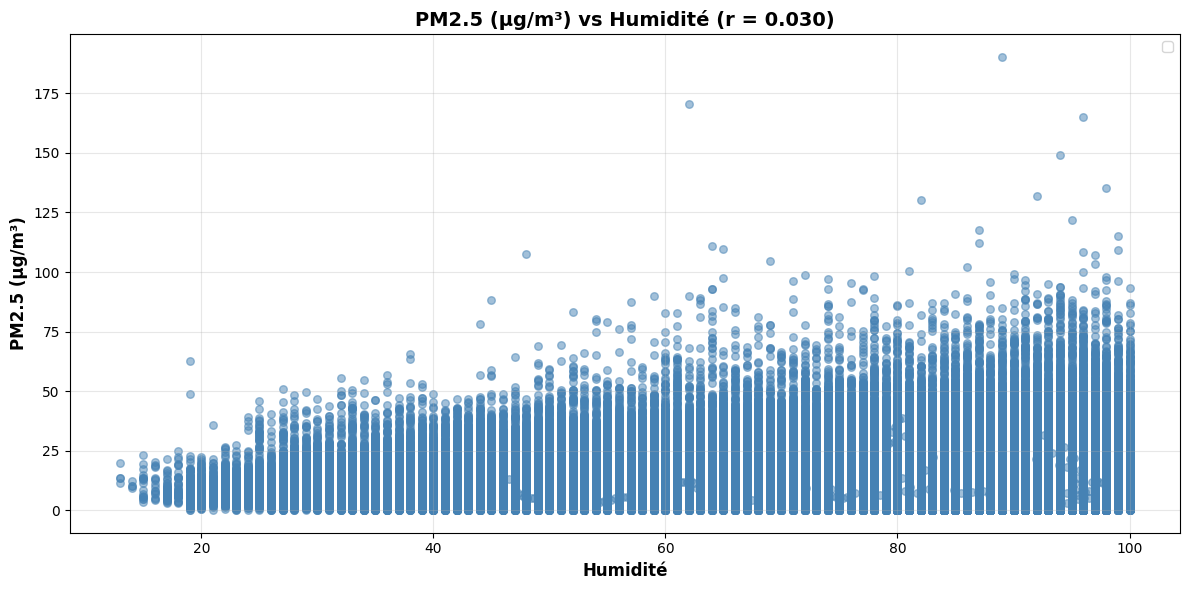

In [59]:
from src.data_preprocessing import graphique_scatter_pm25

print(graphique_scatter_pm25(df, "humidite_pct", "pm25_brute", "Humidité", "PM2.5 (µg/m³)"))

(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'Distribution de humidite_pct par dépassement de seuil'}, xlabel='humidite_pct', ylabel='Densité'>)


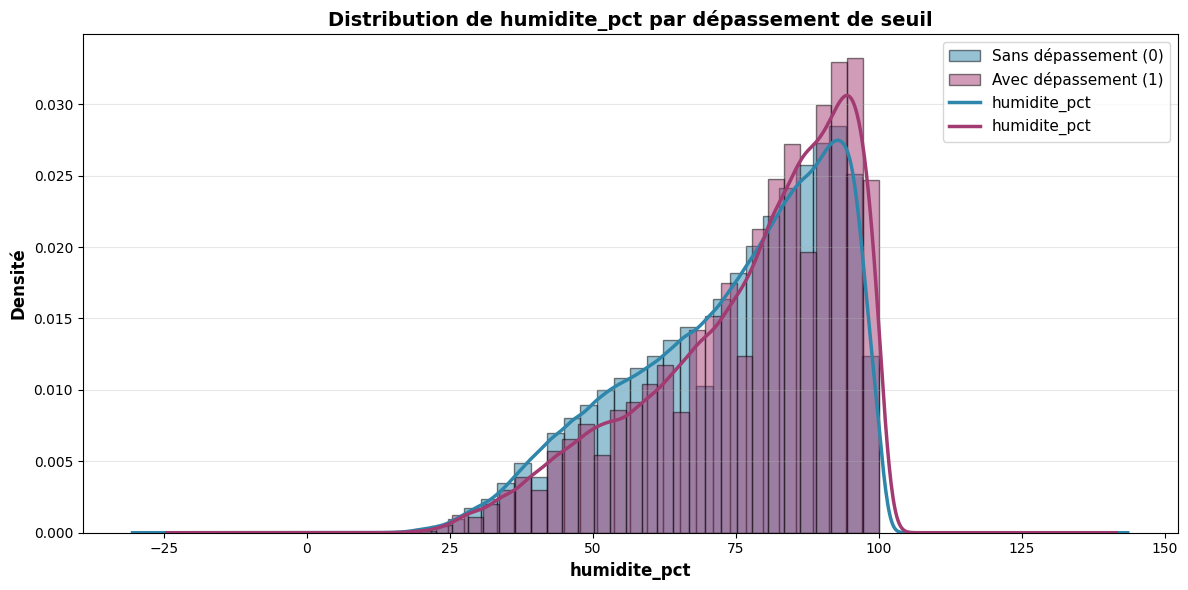

In [60]:
from src.data_preprocessing import histogramme_densité_superposée

print(histogramme_densité_superposée(df, "humidite_pct"))

/home/onyxia/work/projet-qualite-air/src/data_preprocessing.py:744: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1200x600 with 1 Axes>, <Axes: title={'center': 'PM2.5 (µg/m³) vs Précipitations mm (r = -0.162)'}, xlabel='Précipitations mm', ylabel='PM2.5 (µg/m³)'>)


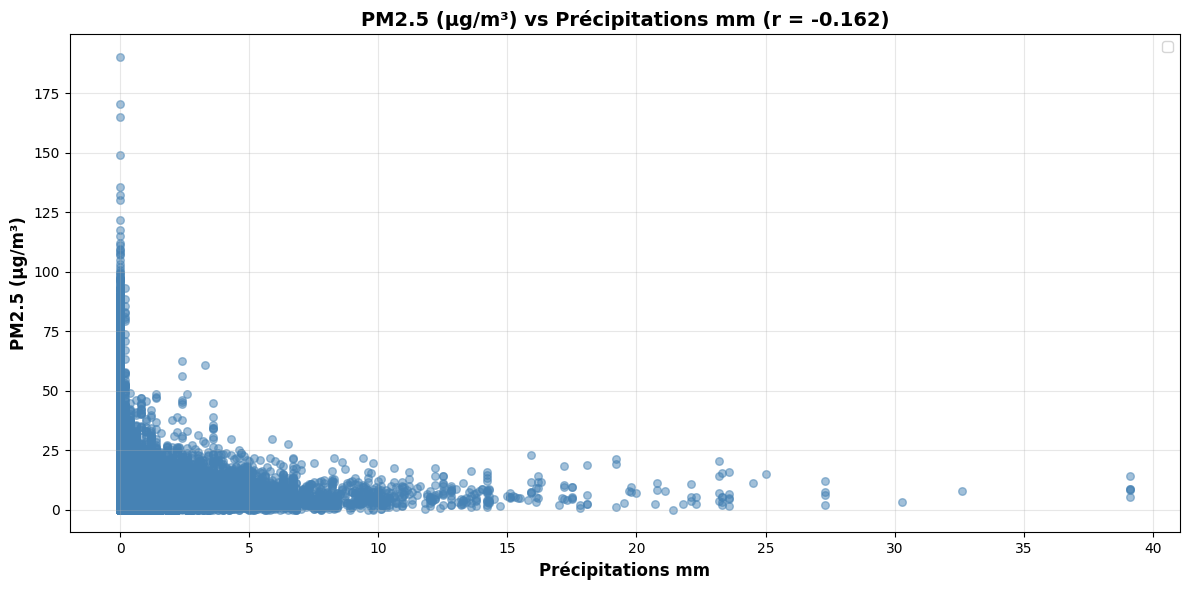

In [61]:
from src.data_preprocessing import graphique_scatter_pm25

print(graphique_scatter_pm25(df, "pluie_mm", "pm25_brute", "Précipitations mm", "PM2.5 (µg/m³)"))

In [62]:
from src.data_preprocessing import tracer_comparaison_carto

print(tracer_comparaison_carto(df, 2024, "nom_station", "pm25_brute", "nb_installations_5km", "lat", "lon", "annee"))

None


## 5. ANALYSE DE PERSISTANCE (AUTO-CORRÉLATION)

(<Figure size 1400x600 with 1 Axes>, <Axes: title={'center': 'ACF - Autocorrélation de PM2.5'}, xlabel='Retard (heures)', ylabel='ACF'>)


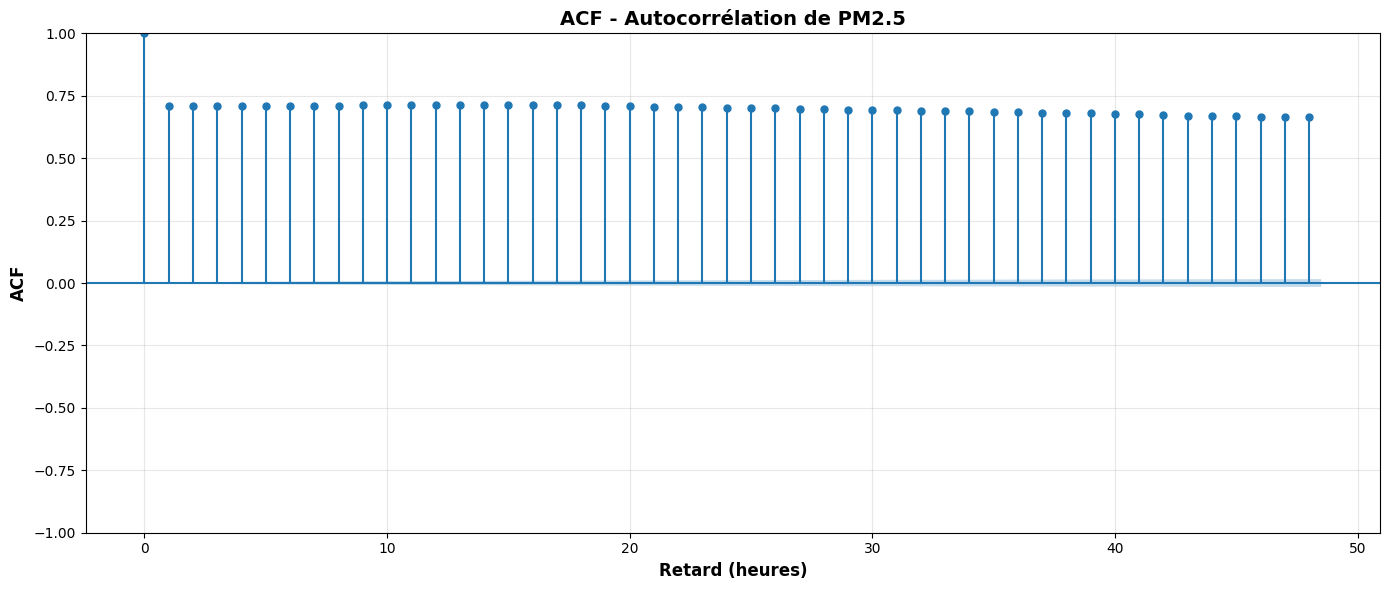

In [63]:
from src.data_preprocessing import graphique_acf_pm25

print(graphique_acf_pm25(df, "pm25_brute", "datetime_debut"))

(<Figure size 1400x600 with 1 Axes>, <Axes: title={'center': 'PACF - Autocorrélation Partielle de PM2.5'}, xlabel='Retard (heures)', ylabel='PACF'>)


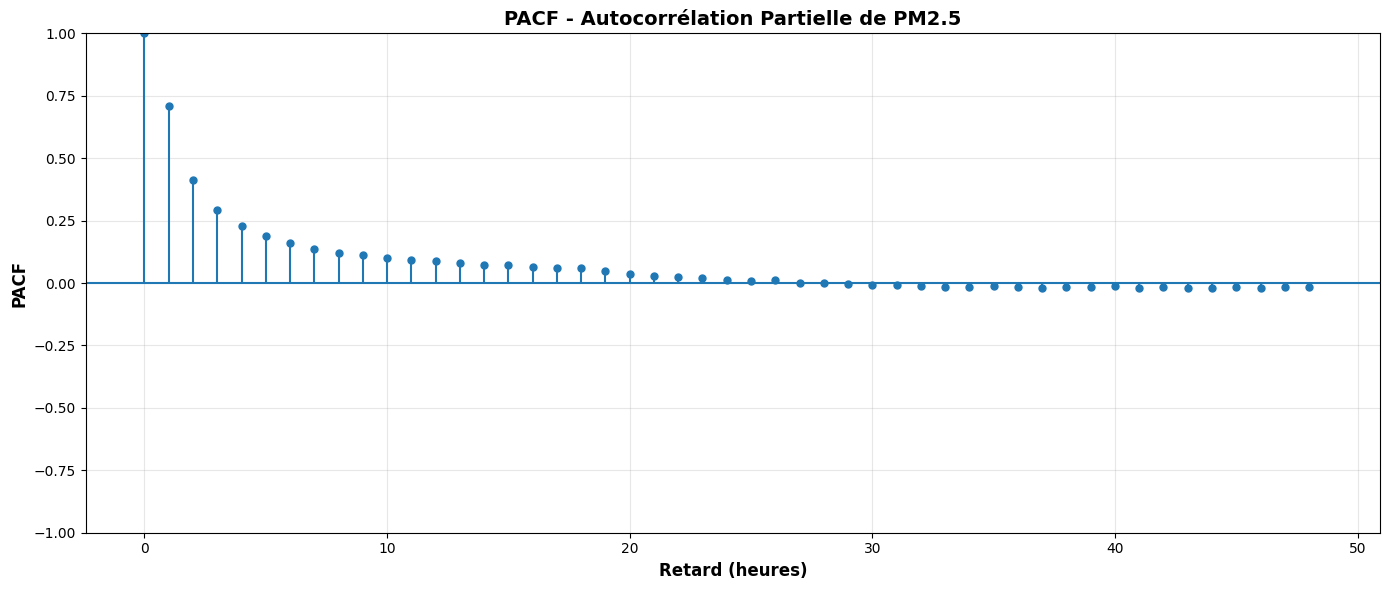

In [64]:
from src.data_preprocessing import graphique_pacf_pm25

print(graphique_pacf_pm25(df, "pm25_brute", "datetime_debut"))